<a href="https://colab.research.google.com/github/Moez145/day-1-mlintern/blob/main/Pandas_Rection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I will develop a social-media data processing and analysis module using Pandas for the nonprofit organization's sentiment dashboard. I will collect social-media data through the Hugging Face API and convert it into a Pandas DataFrame. I will clean, validate, and analyze the data using Pandas, while applying basic NLP techniques to process the text and generate useful insights. Finally, I will encode the labels, test the processing pipeline with multiple cases, and document the results for integration into the dashboard.


In [61]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder

In [62]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [63]:
url = "https://datasets-server.huggingface.co/rows?dataset=socialmediaie%2FSocialMediaIE-MetaCorpus-v1&config=abusive-founta&split=train&offset=0&length=100"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    df = pd.DataFrame(
        [item["row"] for item in data["rows"]]
    )

    print("Data loaded successfully!")
    print("Dataset shape:", df.shape)

else:
    print("Error while loading data:", response.status_code)

Data loaded successfully!
Dataset shape: (100, 3)


In [64]:
display(df.head())

,tweet_id,text,label
0,850490912954351616,Alex Brosas another idiot #ALDUBKSGoesToUS ht...,abusive
1,848791766853668864,"RT @ItIzBiz: as Nancy Reagan would say, 'just ...",abusive
2,850010509969465344,RT @MailOnline: The Nazi death gas so horrific...,normal
3,848619867506913282,RT @chevleia: don't hmu when u get tired of ur...,abusive
4,850449456445235200,RT @Auria__: Can't even feel bad for females w...,hateful


In [65]:
print("Columns:")
print(df.columns.tolist())

Columns:
['tweet_id', 'text', 'label']


In [66]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100
Columns: 3


In [67]:
df.head()

,tweet_id,text,label
0,850490912954351616,Alex Brosas another idiot #ALDUBKSGoesToUS ht...,abusive
1,848791766853668864,"RT @ItIzBiz: as Nancy Reagan would say, 'just ...",abusive
2,850010509969465344,RT @MailOnline: The Nazi death gas so horrific...,normal
3,848619867506913282,RT @chevleia: don't hmu when u get tired of ur...,abusive
4,850449456445235200,RT @Auria__: Can't even feel bad for females w...,hateful


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tweet_id  100 non-null    int64 
 1   text      100 non-null    object
 2   label     100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [69]:
df.describe()

,tweet_id
count,1.000000e+02
mean,8.492014e+17
std,8.769235e+14
min,8.474348e+17
25%,8.486081e+17
50%,8.490833e+17
75%,8.498240e+17
max,8.508334e+17


In [70]:
df.describe(include='object')

,text,label
count,100,100
unique,92,3
top,@Pineaqples @DenialEsports btw I watched where...,abusive
freq,2,70


In [71]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
tweet_id    0
text        0
label       0
dtype: int64


In [72]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

print(missing_percentage)

tweet_id    0.0
text        0.0
label       0.0
dtype: float64


In [73]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 6


In [74]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (94, 3)


In [75]:
print(df['label'].value_counts())

label
abusive    67
hateful    16
normal     11
Name: count, dtype: int64


In [76]:
label_percentage = df['label'].value_counts(normalize=True) * 100

print(label_percentage)

label
abusive    71.276596
hateful    17.021277
normal     11.702128
Name: proportion, dtype: float64


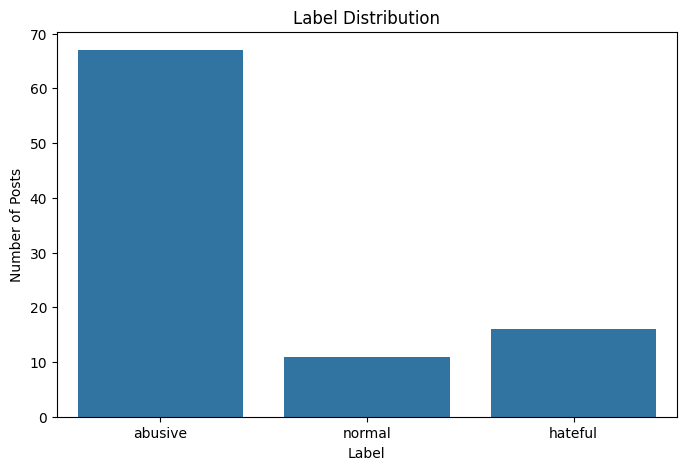

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='label'
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Posts")

plt.show()

In [78]:
print(df['text'].head())

0    Alex Brosas another idiot #ALDUBKSGoesToUS  ht...
1    RT @ItIzBiz: as Nancy Reagan would say, 'just ...
2    RT @MailOnline: The Nazi death gas so horrific...
3    RT @chevleia: don't hmu when u get tired of ur...
4    RT @Auria__: Can't even feel bad for females w...
Name: text, dtype: object


In [79]:
print("Missing text:", df['text'].isnull().sum())

Missing text: 0


In [80]:
df['text_length'] = df['text'].astype(str).apply(len)

In [81]:
df[['text', 'text_length']].head()

,text,text_length
0,Alex Brosas another idiot #ALDUBKSGoesToUS ht...,67
1,"RT @ItIzBiz: as Nancy Reagan would say, 'just ...",112
2,RT @MailOnline: The Nazi death gas so horrific...,98
3,RT @chevleia: don't hmu when u get tired of ur...,75
4,RT @Auria__: Can't even feel bad for females w...,111


In [82]:
print(
    "Average text length:",
    df['text_length'].mean()
)

Average text length: 97.56382978723404


In [83]:
print(
    "Longest post:",
    df['text_length'].max()
)

Longest post: 172


In [84]:
print(
    "Shortest post:",
    df['text_length'].min()
)

Shortest post: 51


In [85]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol
    text = re.sub(r'#', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [86]:
df['clean_text'] = df['text'].apply(clean_text)

In [87]:
df[['text', 'clean_text']].head(10)

,text,clean_text
0,Alex Brosas another idiot #ALDUBKSGoesToUS ht...,alex brosas another idiot aldubksgoestous
1,"RT @ItIzBiz: as Nancy Reagan would say, 'just ...",rt as nancy reagan would say just say fucking ...
2,RT @MailOnline: The Nazi death gas so horrific...,rt the nazi death gas so horrific even hitler ...
3,RT @chevleia: don't hmu when u get tired of ur...,rt dont hmu when u get tired of ur boring hoe ...
4,RT @Auria__: Can't even feel bad for females w...,rt cant even feel bad for females who are stuc...
5,RT @electricpunany: i HATE how some of u ignor...,rt i hate how some of u ignore the fact that u...
6,But he still with the shits so he started smok...,but he still with the shits so he started smok...
7,RT @Configa: April Fools fucking #dope If you ...,rt april fools fucking dope if you aint feelin...
8,Niggas keep talking about women wearing weave ...,niggas keep talking about women wearing weave ...
9,"""God, you're fucking pathetic."" https://t.co/u...",god youre fucking pathetic


In [89]:
word_tokens = []

for text in df['clean_text']:

    tokens = word_tokenize(text)

    word_tokens.append(tokens)

print(word_tokens[:5])

[['alex', 'brosas', 'another', 'idiot', 'aldubksgoestous'], ['rt', 'as', 'nancy', 'reagan', 'would', 'say', 'just', 'say', 'fucking', 'no', 'or', 'something', 'like', 'that'], ['rt', 'the', 'nazi', 'death', 'gas', 'so', 'horrific', 'even', 'hitler', 'feared', 'using', 'it'], ['rt', 'dont', 'hmu', 'when', 'u', 'get', 'tired', 'of', 'ur', 'boring', 'hoe', 'ur', 'boring', 'now', 'too'], ['rt', 'cant', 'even', 'feel', 'bad', 'for', 'females', 'who', 'are', 'stuck', 'on', 'a', 'nigga', 'that', 'disrespects', 'them', 'you', 'gon', 'learn', 'sis']]


In [90]:
stop_words = set(stopwords.words('english'))
filtered_tokens = []

for tokens in word_tokens:

    filtered = [
        word for word in tokens
        if word not in stop_words
    ]

    filtered_tokens.append(filtered)
print(filtered_tokens[:5])

[['alex', 'brosas', 'another', 'idiot', 'aldubksgoestous'], ['rt', 'nancy', 'reagan', 'would', 'say', 'say', 'fucking', 'something', 'like'], ['rt', 'nazi', 'death', 'gas', 'horrific', 'even', 'hitler', 'feared', 'using'], ['rt', 'dont', 'hmu', 'u', 'get', 'tired', 'ur', 'boring', 'hoe', 'ur', 'boring'], ['rt', 'cant', 'even', 'feel', 'bad', 'females', 'stuck', 'nigga', 'disrespects', 'gon', 'learn', 'sis']]


In [92]:
vocab = {}

for tokens in filtered_tokens:

    for word in tokens:

        if word not in vocab:

            vocab[word] = len(vocab) + 1

print("Vocabulary size:", len(vocab))

Vocabulary size: 522


In [93]:
print("Vocabulary size:", len(vocab))
print(list(vocab.items())[:20])

Vocabulary size: 522
[('alex', 1), ('brosas', 2), ('another', 3), ('idiot', 4), ('aldubksgoestous', 5), ('rt', 6), ('nancy', 7), ('reagan', 8), ('would', 9), ('say', 10), ('fucking', 11), ('something', 12), ('like', 13), ('nazi', 14), ('death', 15), ('gas', 16), ('horrific', 17), ('even', 18), ('hitler', 19), ('feared', 20)]


In [94]:
index_token = []

for tokens in filtered_tokens:

    sentence = []

    for word in tokens:

        sentence.append(
            vocab.get(word, 0)
        )

    index_token.append(sentence)
df['index_text'] = index_token
df[['text', 'clean_text', 'index_text']].head()

,text,clean_text,index_text
0,Alex Brosas another idiot #ALDUBKSGoesToUS ht...,alex brosas another idiot aldubksgoestous,"[1, 2, 3, 4, 5]"
1,"RT @ItIzBiz: as Nancy Reagan would say, 'just ...",rt as nancy reagan would say just say fucking ...,"[6, 7, 8, 9, 10, 10, 11, 12, 13]"
2,RT @MailOnline: The Nazi death gas so horrific...,rt the nazi death gas so horrific even hitler ...,"[6, 14, 15, 16, 17, 18, 19, 20, 21]"
3,RT @chevleia: don't hmu when u get tired of ur...,rt dont hmu when u get tired of ur boring hoe ...,"[6, 22, 23, 24, 25, 26, 27, 28, 29, 27, 28]"
4,RT @Auria__: Can't even feel bad for females w...,rt cant even feel bad for females who are stuc...,"[6, 30, 18, 31, 32, 33, 34, 35, 36, 37, 38, 39]"


In [95]:
word_frequency = Counter()

for tokens in filtered_tokens:

    word_frequency.update(tokens)

In [96]:
top_words = word_frequency.most_common(20)

print(top_words)

[('rt', 40), ('fucking', 20), ('bad', 16), ('ass', 14), ('hate', 13), ('dont', 12), ('sick', 10), ('get', 9), ('hell', 9), ('idiot', 8), ('like', 8), ('bitch', 8), ('fuckin', 8), ('im', 7), ('bitches', 7), ('u', 6), ('people', 6), ('nigga', 5), ('amp', 5), ('got', 5)]


In [97]:
top_words_df = pd.DataFrame(
    top_words,
    columns=['word', 'frequency']
)

top_words_df

,word,frequency
0,rt,40
1,fucking,20
2,bad,16
3,ass,14
4,hate,13
5,dont,12
6,sick,10
7,get,9
8,hell,9
9,idiot,8


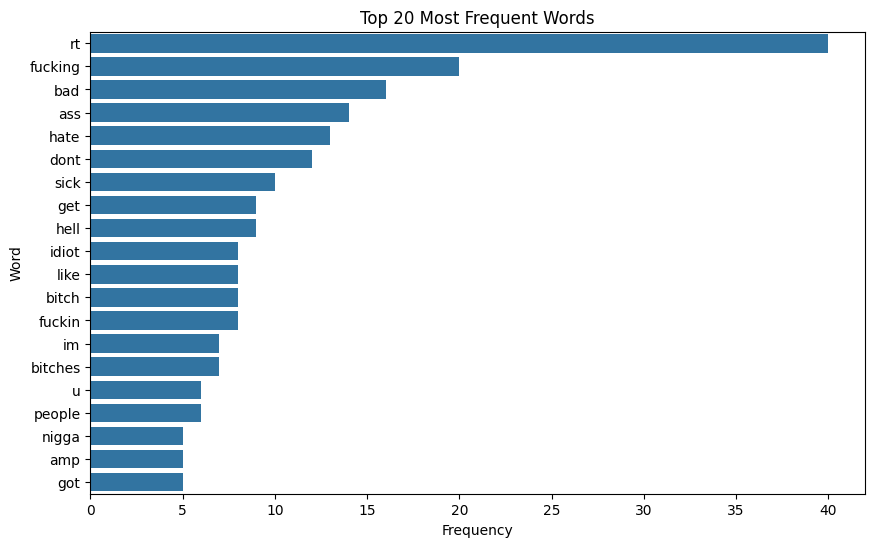

In [98]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words_df,
    x='frequency',
    y='word'
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [99]:
le = LabelEncoder()

df['label_encoded'] = le.fit_transform(df['label'])

In [100]:
label_mapping = dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

print("Label Mapping:")
print(label_mapping)

Label Mapping:
{'abusive': np.int64(0), 'hateful': np.int64(1), 'normal': np.int64(2)}


The module uses Pandas to collect, process, clean, and analyze social-media data obtained from the Hugging Face dataset API. The raw API response is converted into a Pandas DataFrame, where the dataset structure, data types, missing values, duplicate records, and label distribution are examined.

Basic NLP preprocessing is performed on the social-media text. The text is converted to lowercase, URLs, mentions, punctuation, and unnecessary spaces are removed, and the cleaned text is tokenized using NLTK. Stopwords are removed and a vocabulary is created to convert words into numerical indexes.

Pandas is then used to calculate data statistics, label distributions, text-length information, and other dashboard-ready metrics. Label encoding is performed for machine-learning compatibility. Basic error handling is included to detect missing columns, empty datasets, missing text, and other invalid inputs.

The complete processing pipeline is tested using ten test cases covering data loading, required columns, missing values, duplicate detection, text cleaning, tokenization, vocabulary generation, and numerical encoding. The processed results can be provided to the dashboard component for visualization and further analysis.
